In [1]:
import numpy as np
import random
from sklearn.datasets import load_iris
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [5]:
def rast(x,y):
    res = 0
    for i in range(x.shape[0]):
        res += (x[i] - y[i]) ** 2
    return res ** 0.5
def show(dataset,clusters):
    l = np.zeros(dataset.shape[0])
    cur = 1
    for i in clusters.keys():
        for j in clusters[i]:
            l[j] = cur
        cur += 1
    df = pd.DataFrame(dataset, columns=['feature1', 'feature2', 'feature3', 'feature4'])
    df['Cluster'] = l
    sns.pairplot(df, hue="Cluster")
    plt.show()
    
        
class Kmeans:
    def __init__(self,n_clusters = 3):
        self.n_clusters = n_clusters
    def fit_predict(self,dataset,to_show = True):
        if to_show:
            pca = PCA(n_components=2)
            low_dataset = pca.fit_transform(dataset)
        centroids = dataset[random.sample(range(dataset.shape[0]),self.n_clusters)]
        while True:
            clusters = {}
            l = []
            for i in range(dataset.shape[0]):
                dist = [rast(dataset[i],cl) for cl in centroids]
                cluster_num = np.argmin(dist)
                if cluster_num not in clusters:
                    clusters[cluster_num] = []
                clusters[cluster_num].append(i)
                l.append(cluster_num)
            if to_show:
                plt.scatter(low_dataset[:,0],low_dataset[:,1],c=l)
                low_centroids = pca.fit_transform(centroids)
                plt.scatter(low_centroids[:,0],low_centroids[:,1],c='red')
                plt.show()
            copy_centr = centroids.copy()
            for i in clusters.keys():
                cen = dataset[clusters[i]]
                for j in range(dataset.shape[1]):
                    centroids[i][j] = np.mean([k[j] for k in cen])
            raznica = np.sum(np.abs(centroids - copy_centr))
            if raznica == 0:
                if to_show:
                    show(dataset,clusters)
                return centroids

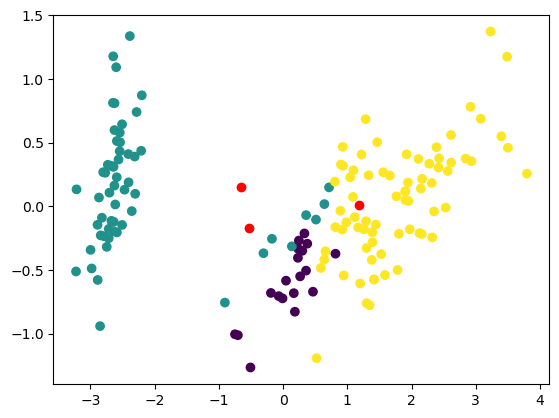

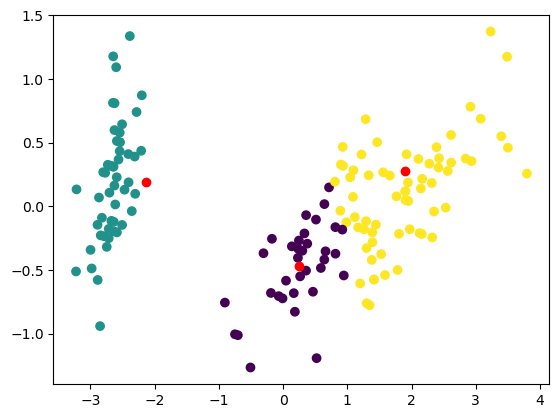

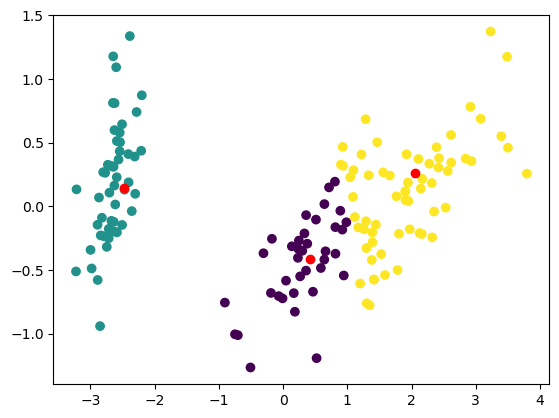

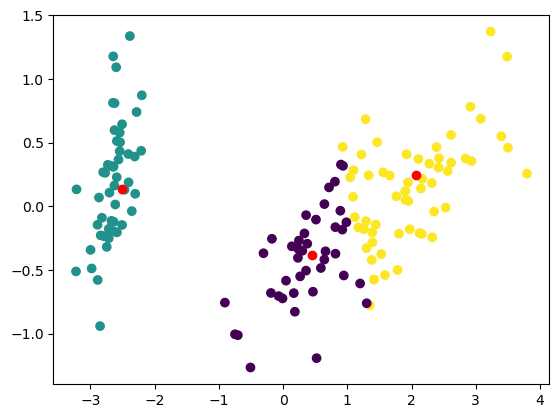

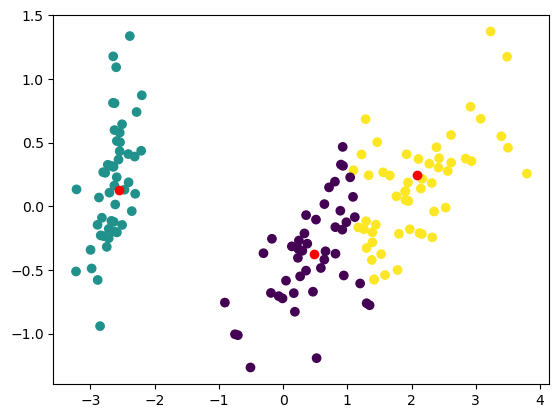

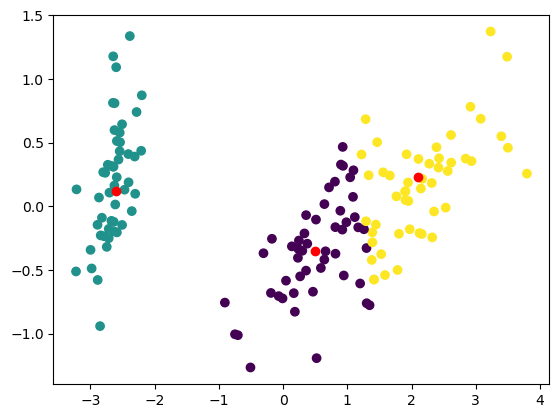

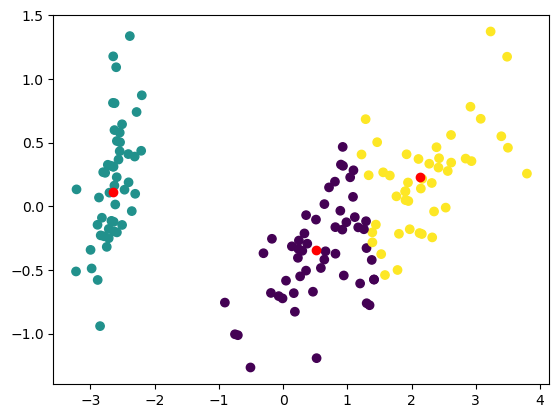

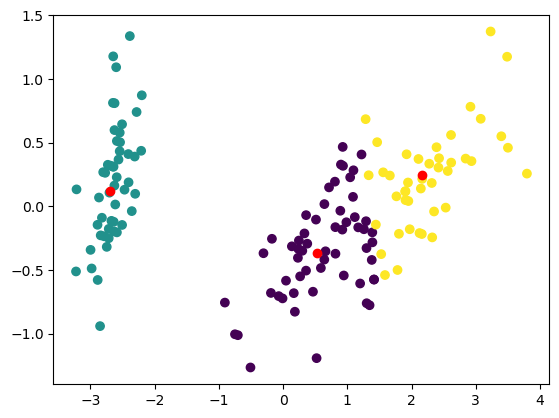

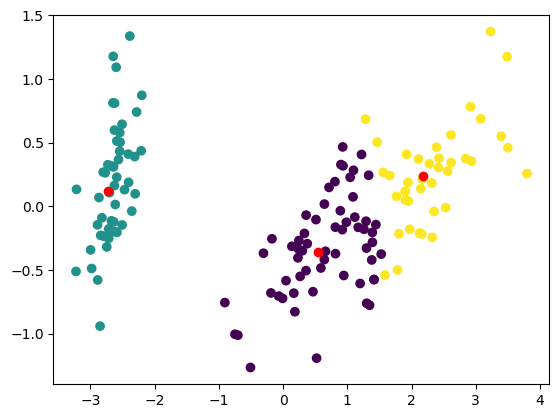

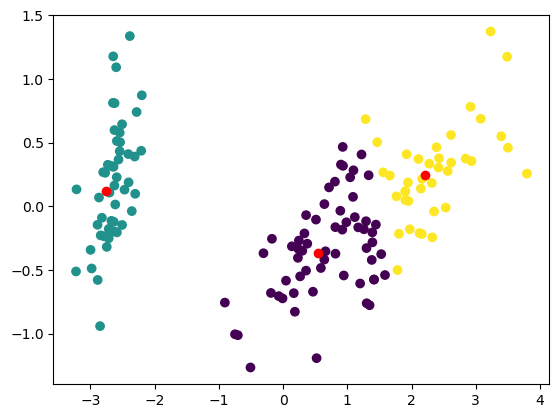

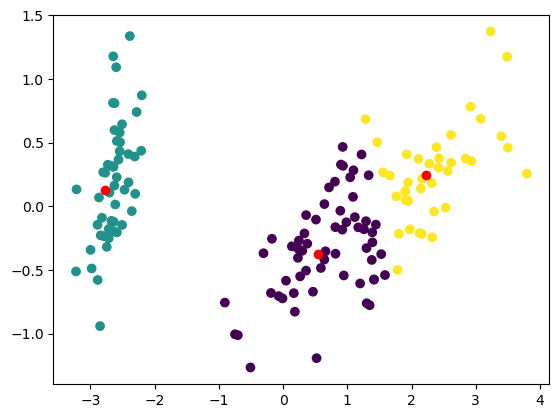

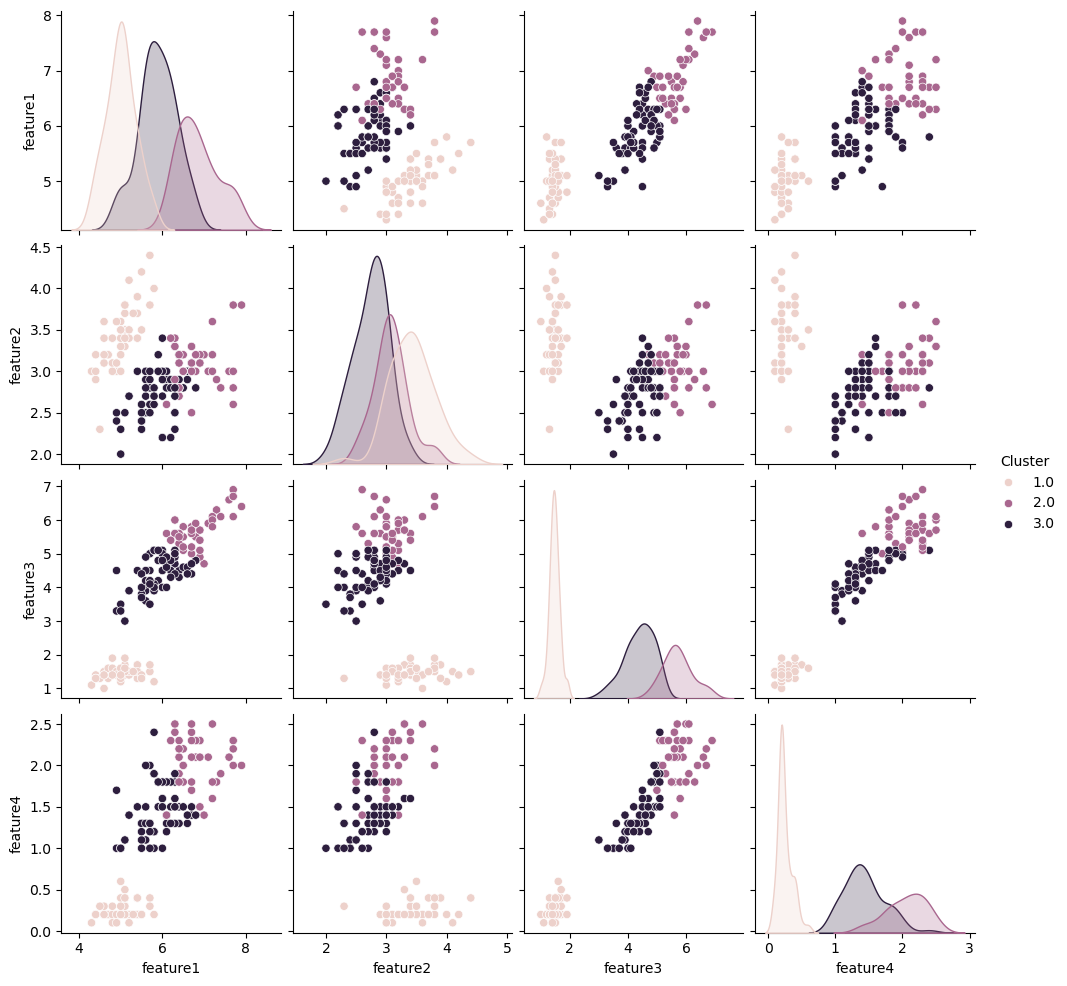

array([[5.88360656, 2.74098361, 4.38852459, 1.43442623],
       [5.006     , 3.428     , 1.462     , 0.246     ],
       [6.85384615, 3.07692308, 5.71538462, 2.05384615]])

In [6]:
dataset = load_iris()

l = Kmeans()
f = l.fit_predict(dataset.data)
f

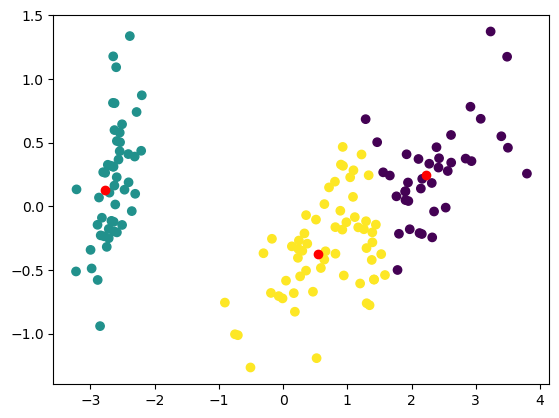

In [7]:
from sklearn.cluster import KMeans
pca = PCA(n_components=2)
low_data = pca.fit_transform(dataset.data)
k = KMeans(n_clusters = 3)
k.fit(dataset.data)
# df = pd.DataFrame(dataset.data, columns=['feature1', 'feature2', 'feature3', 'feature4'])
# df['Cluster'] = k.fit_predict(dataset.data)
# sns.pairplot(df, hue="Cluster")
plt.scatter(low_data[:,0],low_data[:,1],c=k.predict(dataset.data))
low_centr = pca.fit_transform(k.cluster_centers_)
plt.scatter(low_centr[:,0],low_centr[:,1],c='red')
plt.show()

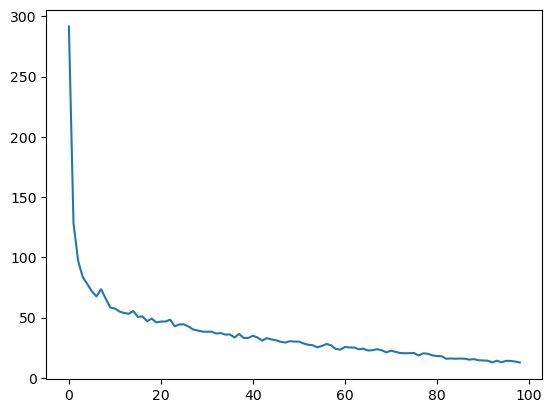

In [13]:
dataset = load_iris()
results = []
for i in range(1,100):
    cur = 0
    l = Kmeans(i)
    f = l.fit_predict(dataset.data,to_show=False)
    for i in dataset.data:
        cur += min([rast(i,j) for j in f])
    results.append(cur)
plt.plot(results)
plt.show()